In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("C:/Users/Nikhil/Documents/Nikhil/Project/Data Analytics/netflix-analytics/netflix_titles.csv")

In [7]:
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

First 5 Rows
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24,

In [ ]:
print("\nMissing Values")
print(df.isnull().sum())

missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing Value Percentage")
print(missing_percent)


Missing Values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing Value Percentage
show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [9]:
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)


Duplicate Rows: 0


In [10]:
print("\nNumerical Summary")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include='object'))


Numerical Summary
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000

Categorical Summary
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   

              country       date_added rating  duration  \
count            7976             8797   8803      8804   
unique            748             1767     17       220   
top     United States  January 1, 2020  TV-MA  1 Season   
freq             2818              109   3207      1793   

                           listed_in  \
count                           8807   
unique                           514   
top     Dramas, Interna

In [11]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nTop Values in {col}")
    print(df[col].value_counts().head(10))


Top Values in show_id
show_id
s8807    1
s1       1
s2       1
s3       1
s4       1
s5       1
s6       1
s8791    1
s8790    1
s8789    1
Name: count, dtype: int64

Top Values in type
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top Values in title
title
Zubaan                           1
Dick Johnson Is Dead             1
Blood & Water                    1
Ganglands                        1
Jailbirds New Orleans            1
Kota Factory                     1
Midnight Mass                    1
You Don't Mess with the Zohan    1
You Changed My Life              1
You Carry Me                     1
Name: count, dtype: int64

Top Values in director
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int6

In [12]:
numeric_df = df.select_dtypes(include=np.number)

if len(numeric_df.columns) > 1:
    correlation = numeric_df.corr()

    plt.figure(figsize=(10, 6))
    plt.imshow(correlation, cmap='coolwarm')
    plt.colorbar()
    plt.xticks(range(len(correlation.columns)),
               correlation.columns,
               rotation=90)
    plt.yticks(range(len(correlation.columns)),
               correlation.columns)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

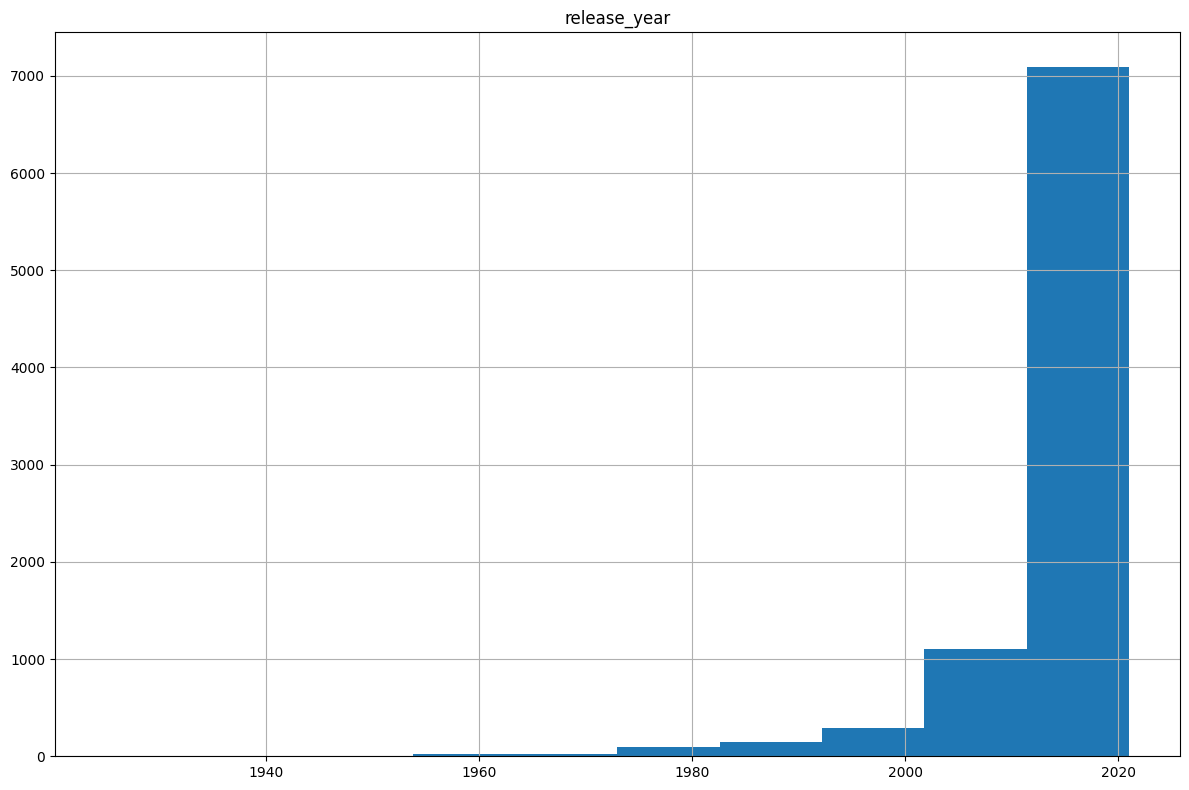

In [13]:
numeric_df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


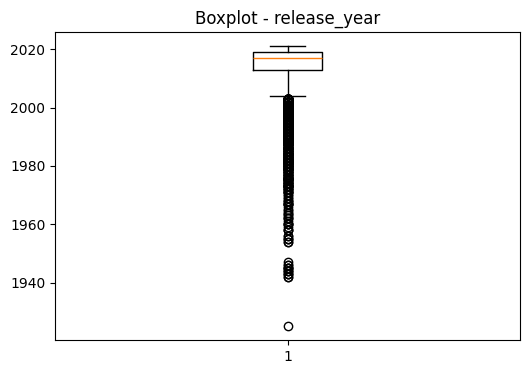

In [14]:
for col in numeric_df.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.show()


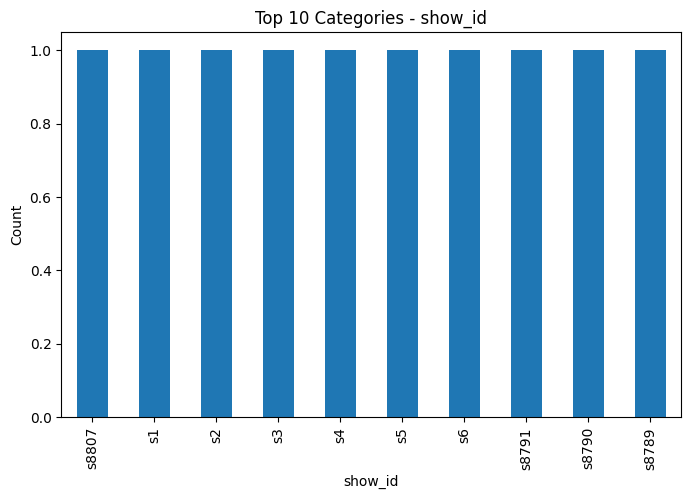

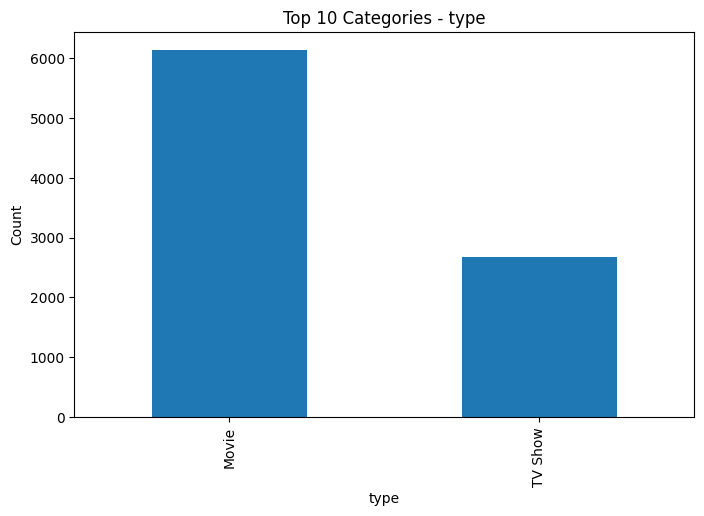

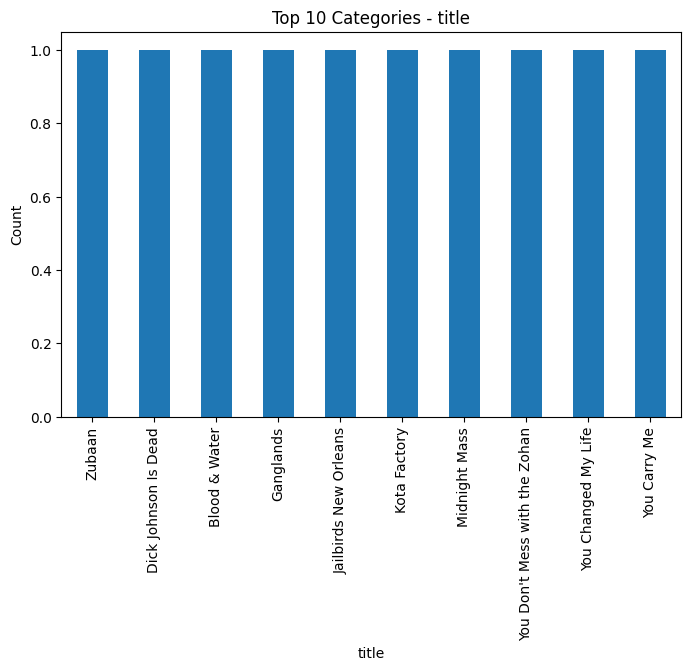

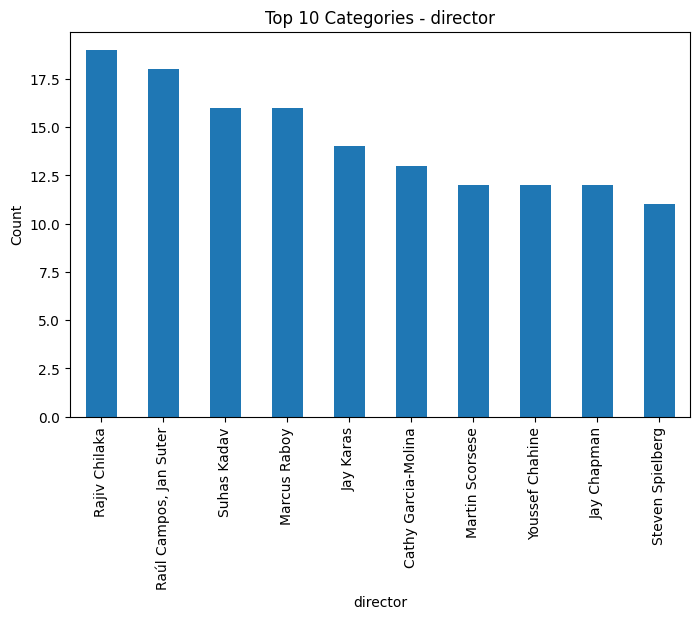

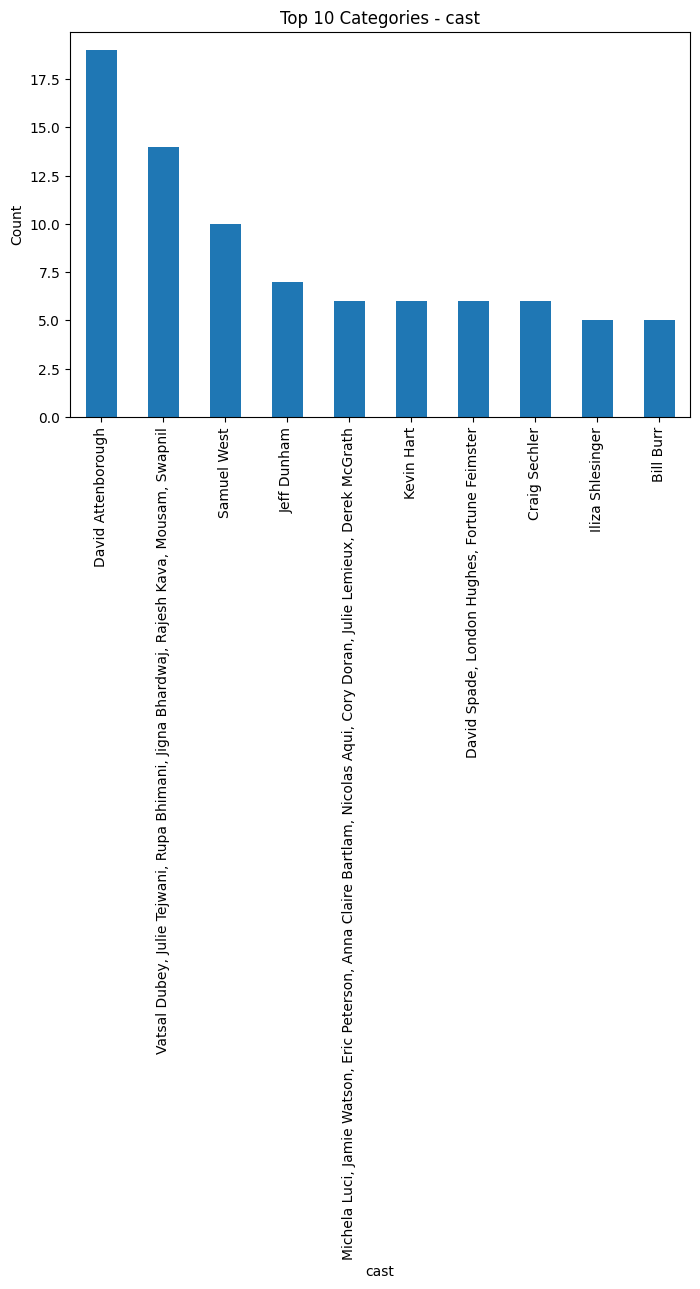

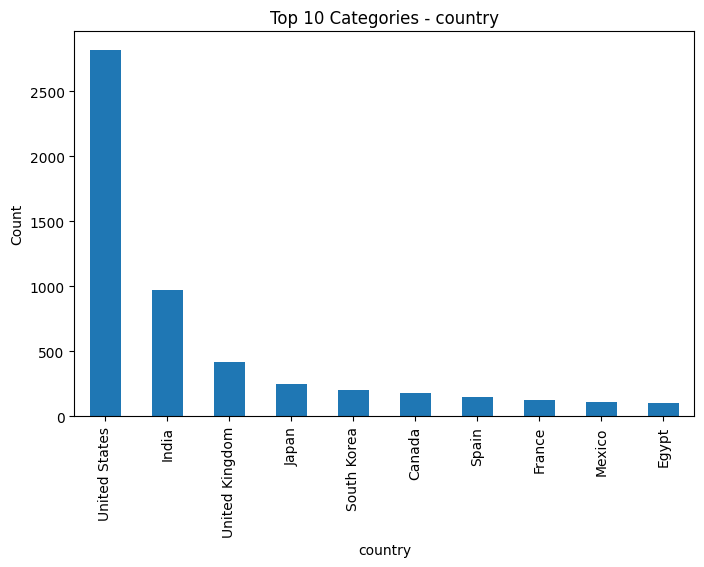

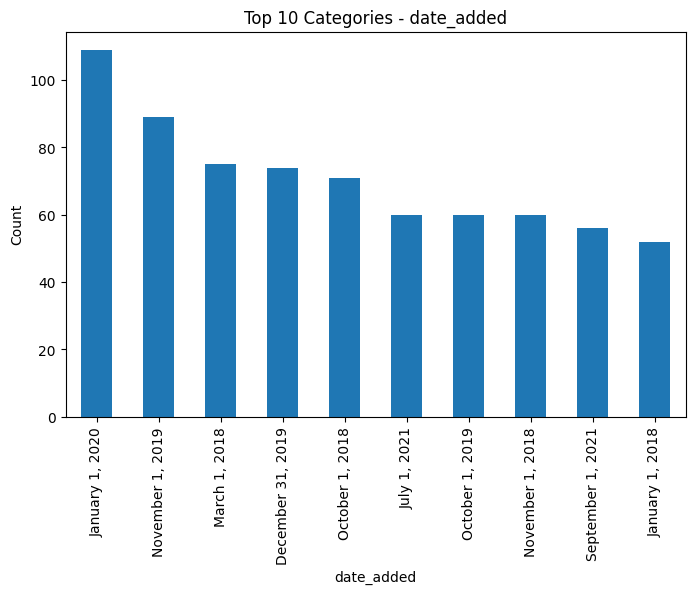

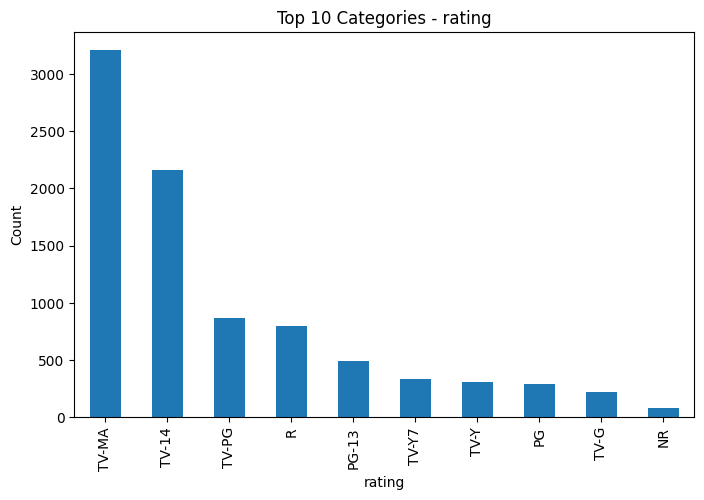

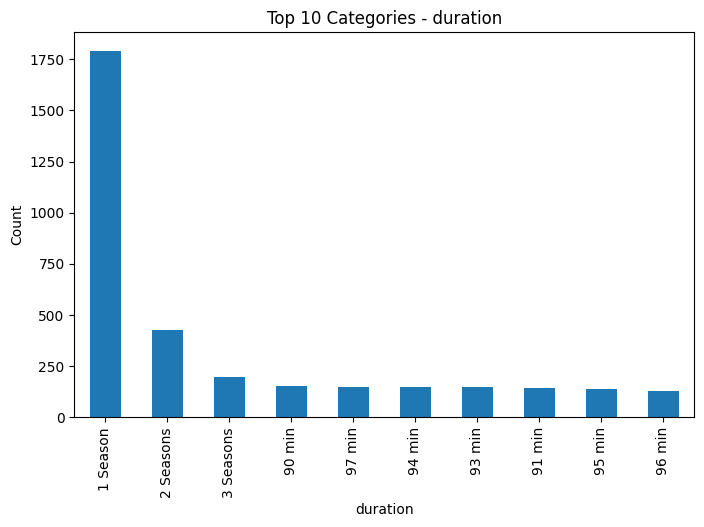

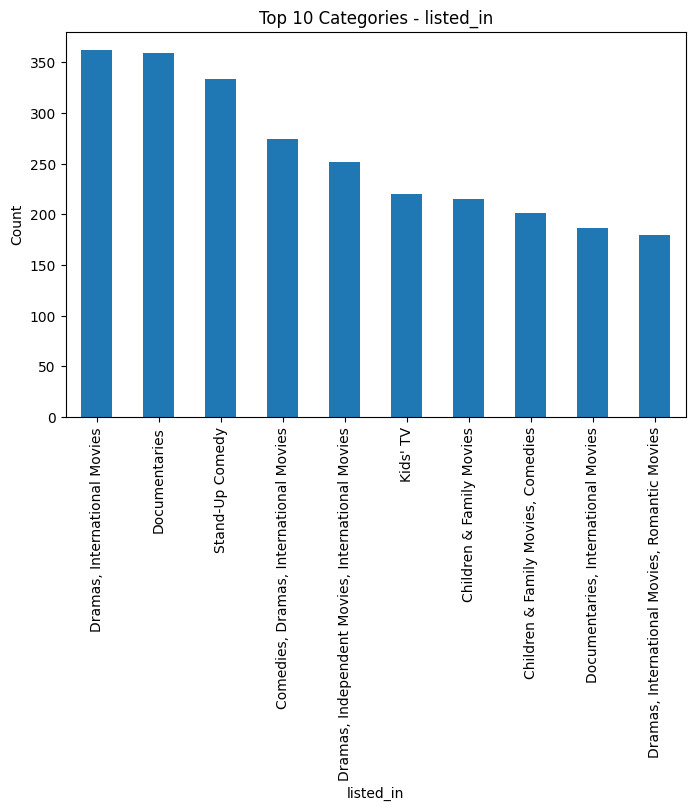

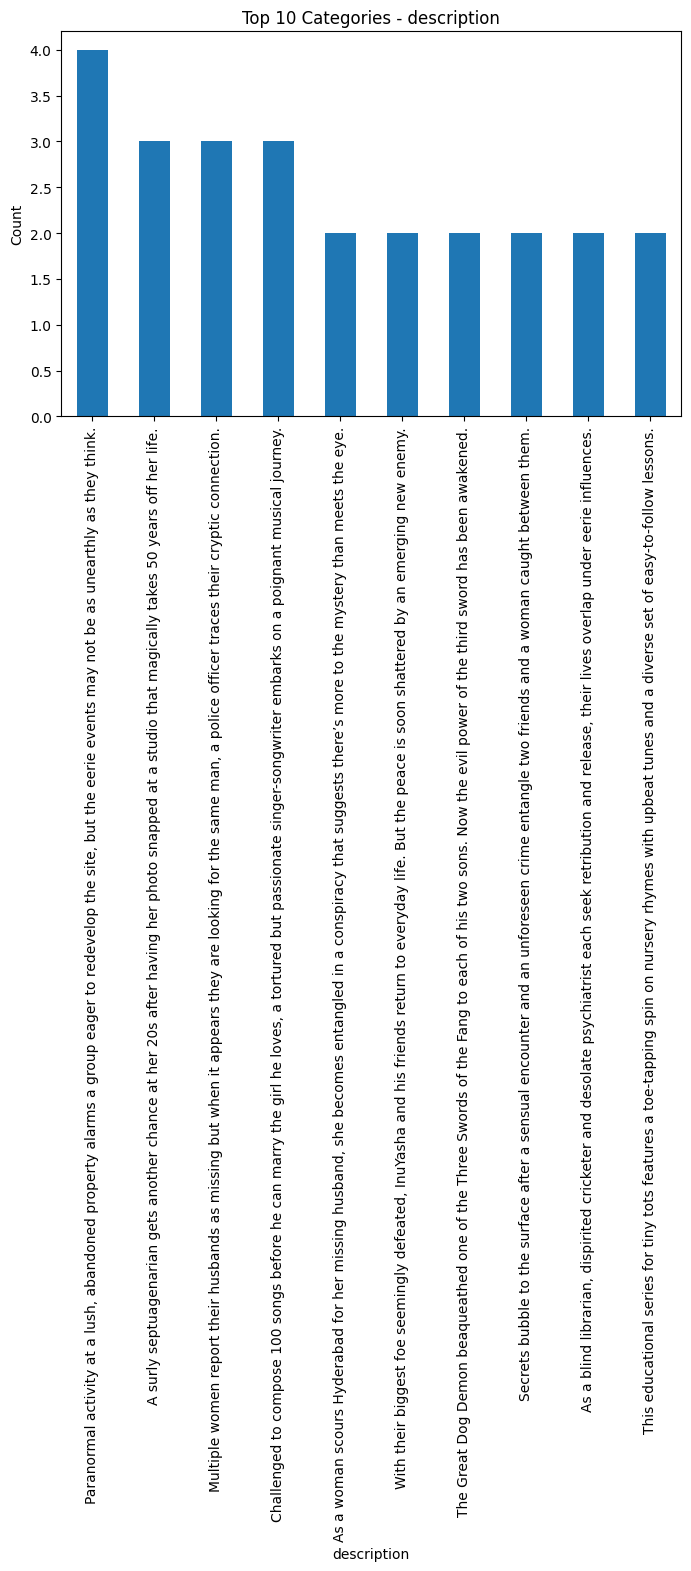

In [15]:
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(8,5))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top 10 Categories - {col}")
    plt.ylabel("Count")
    plt.show()
